# **Evasion Attack against SVM**


**1. Shell installs (enviroment setup)**

In [ ]:
# !apt install -y libboost-all-dev
# !pip install -U pip
# !pip install "pybind11[global]"

# !pip install aijack

In [10]:
# !apt-get update -qq
# !apt-get install -y --fix-missing \
#   libboost-filesystem-dev libboost-system-dev libboost-thread-dev \
#   libboost-serialization-dev libboost-regex-dev libboost-program-options-dev \
#   libboost-date-time-dev libboost-iostreams-dev libboost-log-dev \
#   libboost-random-dev libboost-math-dev libboost-chrono-dev

# !pip install aijack

#If !pip install aijack still fails, run this to see the full error:
#!pip install aijack -v 2>&1 | tail -60

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libboost-atomic1.74-dev libboost-atomic1.74.0 libboost-chrono1.74-dev
  libboost-chrono1.74.0 libboost-date-time1.74-dev libboost-date-time1.74.0
  libboost-filesystem1.74-dev libboost-filesystem1.74.0
  libboost-iostreams1.74-dev libboost-iostreams1.74.0 libboost-log1.74-dev
  libboost-log1.74.0 libboost-math1.74-dev libboost-math1.74.0
  libboost-program-options1.74-dev libboost-program-options1.74.0
  libboost-random1.74-dev libboost-random1.74.0 libboost-regex1.74-dev
  libboost-regex1.74.0 libboost-serialization1.74-dev
  libboost-serialization1.74.0 libboost-system1.74-dev libboost-system1.74.0
  libboost-thread1.74-dev libboost-thread1.74.0
The

**2. Imports**

In [12]:
import os
import time
import copy

import numpy as np
import sklearn
from sklearn import datasets
from sklearn import metrics
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

import aijack.attack
from aijack.attack import Evasion_attack_sklearn

**3. Loading MNIST**

In [13]:
# Importing necessary libraries
from sklearn import datasets
from sklearn.model_selection import train_test_split

# Fetching the MNIST dataset
mnist = datasets.fetch_openml("mnist_784", version=1, data_home=".", return_X_y=True)
imagedata, labeldata = mnist[0].values, mnist[1].values

**4. Select only digits 3 and 7 (filter dataset)**

In [14]:
# Extracting indices of images labeled as '3' and '7'
index_3 = [i for i, x in enumerate(labeldata) if x == "3"]
index_7 = [i for i, x in enumerate(labeldata) if x == "7"]

# Combining image and label data for digits '3' and '7'
image_data_3_7 = imagedata[index_3 + index_7]
label_data_3_7 = labeldata[index_3 + index_7]

**5. Train/validation split**

In [15]:
# Splitting the data into training and validation sets
imagedata_training, imagedata_validation, labeldata_training, labeldata_validation = \
    train_test_split(image_data_3_7, label_data_3_7, test_size=0.2, shuffle=True)


**6. Normalization**

In [16]:
# Normalizing image data
imagedata_training = imagedata_training / 255.0
imagedata_validation = imagedata_validation / 255.0

**7. Subset for speed**

In [17]:
# Selecting a subset for faster training
X_train = imagedata_training[:5000]
y_train = labeldata_training[:5000]
X_valid = imagedata_validation[:500]
y_valid = labeldata_validation[:500]

**8. Train the target classification model (svm)**

In [18]:
# Importing necessary libraries
from sklearn.svm import SVC
from sklearn import metrics

# Initializing Support Vector Classifier (SVC) with linear kernel
clf = SVC(kernel="linear")

# Training the classifier using the training data
clf.fit(X_train, y_train)

# Predicting labels for validation data
predict = clf.predict(X_valid)

# Calculating accuracy score
ac_score = metrics.accuracy_score(y_valid, predict)

# Generating classification report
cl_report = metrics.classification_report(y_valid, predict)

# Printing the classification report
print(cl_report)


              precision    recall  f1-score   support

           3       0.97      0.98      0.98       255
           7       0.98      0.97      0.98       245

    accuracy                           0.98       500
   macro avg       0.98      0.98      0.98       500
weighted avg       0.98      0.98      0.98       500



# Evasion Attack

**9. Prepare the attacker input**

In [19]:
# Extracting training samples labeled as "3"
X_minus_1 = X_train[np.where(y_train == "3")]

**10. Initialize AIJack evasion attacker**

In [20]:
# Initializing the evasion attack instance
attacker = Evasion_attack_sklearn(
    target_model=clf,  # The classifier to be attacked
    X_minus_1=X_minus_1,  # The dataset containing samples labeled as the class the attacker wants to mimic
    dmax=(5000 / 255) * 2.5,  # The maximum perturbation allowed for each feature
    max_iter=300,  # The maximum number of iterations for the attack
    gamma=1 / (X_train.shape[1] * np.var(X_train)),  # A parameter affecting the magnitude of perturbation
    lam=10,  # A regularization parameter
    t=0.5,  # A parameter controlling the trade-off between reducing perturbation and maximizing attack success
    h=10,  # A parameter controlling the step size during the attack
)



11. Choose seed example (7) and run attack

In [21]:
# Selecting a sample from the validation set labeled as "7" as the initial input
x0 = X_valid[np.where(y_valid == "7")[0][0]]

# Performing the evasion attack to generate an adversarial example
xm, g_list = attacker.attack(copy.copy(x0))

**12. Display original vs adversarial**

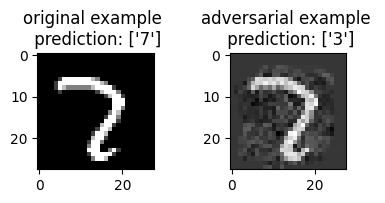

In [22]:
# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(4, 2))

# Display the original example in the first subplot
axes[0].imshow(x0.reshape(28, 28), cmap="gray")  # Display the image
axes[0].set_title(f"original example \n prediction: {clf.predict(x0.reshape(1, -1))}")  # Set title

# Display the adversarial example in the second subplot
axes[1].imshow(xm.reshape(28, 28), cmap="gray")  # Display the image
axes[1].set_title(
    f"adversarial example \n prediction: {clf.predict(xm.reshape(1, -1))}"  # Set title
)

# Adjust layout of subplots
fig.tight_layout()

# Show the figure
# fig.savefig("output_10.png")  # Optionally save the figure as an image file
fig.show()
